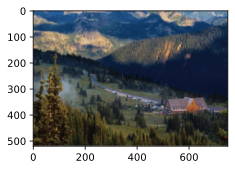

In [3]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

d2l.set_figsize()
content_img = d2l.Image.open('./rainier.jpg')
d2l.plt.imshow(content_img);

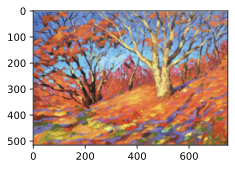

In [4]:
style_img = d2l.Image.open('./autumn-oak.jpg')
d2l.plt.imshow(style_img);

In [5]:
rgb_mean = torch.tensor([0.485, 0.456, 0.406])
rgb_std = torch.tensor([0.229, 0.224, 0.225])
# 这是 ImageNet 数据集上常用的 RGB 三通道均值与标准差（很多预训练模型按这个做训练）。
def preprocess(img, image_shape):
    transforms = torchvision.transforms.Compose([
        # 第一个变换操作 —— 调整图像尺寸。        
        torchvision.transforms.Resize(image_shape)
        # 细节：Resize会将输入图像的宽高调整为image_shape指定的尺寸（若image_shape是元组如(224,224)，则直接缩放到该尺寸；若为单个数值，则按最短边等比例缩放），目的是统一输入图像尺寸，匹配模型的输入要求。
        # 第二个变换操作 —— 将 PIL 图像转为 PyTorch 张量
        torchvision.transforms.ToTensor(),
#         像素值转换：将 PIL 图像中 0-255 的整数像素值，归一化到 0.0-1.0 的浮点数；
# 维度重排：将 PIL 图像的(高度H, 宽度W, 通道C)格式，转为 PyTorch 标准的(通道C, 高度H, 宽度W)格式（通道在前）。
        torchvision.transforms.Normalize(mean=rgb_mean, std=rgb_std)])
#     作用：第三个变换操作 —— 对张量进行标准化（归一化）。
# 计算公式：output = (input - mean) / std，即用每个通道的像素值减去对应通道均值，再除以标准差。
# 注意：必须放在ToTensor之后，因为Normalize要求输入是 0-1 的浮点数张量。
    # 创建变换组合器Compose，它能将多个图像变换操作按顺序 “串联”，调用时会一次性执行所有变换，避免分步操作的繁琐。
    return transforms(img).unsqueeze(0)
#     transforms(img)：对输入的 PIL 图像执行上述串联的变换，得到形状为(C, H, W)的张量；
# unsqueeze(0)：在第 0 维（batch 维度）增加一个维度，最终输出形状为(1, C, H, W)的张量 —— 因为 PyTorch 模型默认接收 “批量数据”，即使单张图像也需要 batch 维度。

def postprocess(img):
    img = img[0].to(rgb_std.device)
#     img[0]：取出 batch 维度的第一个元素，得到形状为(C, H, W)的张量；
# .to(rgb_std.device)：将张量移动到和rgb_std相同的设备（CPU/GPU），避免 “张量在 GPU、均值在 CPU” 的设备不匹配错误。
    img = torch.clamp(img.permute(1, 2, 0) * rgb_std + rgb_mean, 0, 1)
#     img.permute(1, 2, 0)：将张量从(C, H, W)转回(H, W, C)（通道在后），匹配 PIL 图像的维度格式；
# * rgb_std + rgb_mean：执行归一化的逆操作（input = output * std + mean），还原像素值；
# torch.clamp(..., 0, 1)：将像素值裁剪到 0-1 之间 —— 反归一化后可能出现小于 0 或大于 1 的无效值，clamp确保数值合法。
    return torchvision.transforms.ToPILImage()(img.permute(2, 0, 1))
#     img.permute(2, 0, 1)：将张量从(H, W, C)转回(C, H, W)—— 因为ToPILImage要求输入是通道在前的格式；
# torchvision.transforms.ToPILImage()：创建 PIL 图像转换器，将 0-1 的浮点数张量转回 0-255 整数的 PIL 图像；

In [6]:
pretrained_net = torchvision.models.vgg19(pretrained=True)

C:\Users\32536\anaconda3\envs\d2l-env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
C:\Users\32536\anaconda3\envs\d2l-env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\32536/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth
100.0%


In [7]:
style_layers, content_layers = [0, 5, 10, 19, 28], [25]
# style_layers（风格层）：选择[0,5,10,19,28]多个层 —— 风格特征需要从浅层到深层的卷积层提取：
# 浅层（如 0、5 层）：捕捉边缘、纹理、颜色等基础风格信息；
# 深层（如 19、28 层）：捕捉更抽象的高级风格模式（如笔触、构图）。
# content_layers（内容层）：仅选择[25]单一层 —— 内容特征需要深层卷积层（语义层），浅层只保留细节，深层才能表达图像的核心语义（如 “猫”“狗” 的轮廓 / 结构）。

In [8]:
net = nn.Sequential(*[pretrained_net.features[i] for i in
                      range(max(content_layers + style_layers) + 1)])
# pretrained_net.features：VGG 等经典分类网络的features部分，包含所有卷积层、ReLU 层、池化层（不含全连接层），是视觉特征提取的核心（全连接层用于分类，无特征表达能力）；
# content_layers + style_layers：合并内容层和风格层的索引列表，这里得到[0,5,10,19,28,25]；
# max(...)：取合并列表的最大值（这里是 28），即需要保留的最后一层索引；
# range(max(...) + 1)：因为range是 “左闭右开”，+1确保包含索引 28 的层（range(29)覆盖 0~28 层）；
# [pretrained_net.features[i] for i in ...]：生成包含 0~28 层的列表；
# *：解包列表（将列表元素作为独立参数传入）；
# nn.Sequential(...)：将这些层按顺序封装成新的Sequential网络，后续仅需前向传播这个截断网络即可完成特征提取。

In [9]:
def extract_features(X, content_layers, style_layers):
    contents = []
    styles = []
    for i in range(len(net)):
        X = net[i](X)
#         作用：将张量X传入当前层（net[i]）进行前向计算，更新X为当前层的输出特征图。
# 关键：每一层的输出是下一层的输入，因此X会依次变成 “原始图像→第一层特征→第二层特征→…→第 28 层特征”。
        if i in style_layers:
            styles.append(X)
        if i in content_layers:
            contents.append(X)
    return contents, styles

In [10]:
def get_contents(image_shape, device):
    content_X = preprocess(content_img, image_shape).to(device)
#     preprocess(content_img, image_shape)：调用之前定义的preprocess函数，将原始的content_img（PIL 图像）转为模型可输入的张量（形状为(1, 3, H, W)，batch=1、3 通道、高 H、宽 W）；
# .to(device)：将预处理后的张量迁移到指定设备（GPU/CPU）—— 这是必须的步骤，因为后续特征提取网络（net）的参数也在该设备上，张量和模型参数需在同一设备才能计算；
# content_X：最终得到 “预处理 + 设备对齐” 的内容图像张量。
    contents_Y, _ = extract_features(content_X, content_layers, style_layers)
#     extract_features(...)：调用之前定义的特征提取函数，传入预处理后的内容图像张量、内容层 / 风格层索引；
# contents_Y：接收函数返回的第一个值 —— 内容图像在content_layers（如[25]）上的特征列表，这是后续优化的 “内容基准”（生成图像的内容特征要尽量和它一致）；
# _：Python 的占位符，用于忽略函数返回的第二个值（风格特征列表）—— 因为我们只关心内容图像的 “内容”，它的风格特征对风格迁移没有意义，无需保留。
    return content_X, contents_Y

def get_styles(image_shape, device):
    style_X = preprocess(style_img, image_shape).to(device)
    _, styles_Y = extract_features(style_X, content_layers, style_layers)
    return style_X, styles_Y

In [11]:
def content_loss(Y_hat, Y):
    # 我们从动态计算梯度的树中分离目标：
    # 这是一个规定的值，而不是一个变量。
    return torch.square(Y_hat - Y.detach()).mean()

In [13]:
def gram(X):
    num_channels, n = X.shape[1], X.numel() // X.shape[1]
#     X.shape[1]：获取特征张量的通道数 C（因为X的形状是(1, C, H, W)，索引 1 对应通道维度）；
# X.numel()：计算X的总元素数（即 1*C*H*W）；
# X.numel() // X.shape[1]：总元素数 ÷ 通道数 = 每个通道的元素数 n = H*W（把每个通道的特征图展平成 1 维向量后的长度）；
# 示例：若X形状为(1, 64, 224, 224)，则num_channels=64，n=224*224=50176。
    X = X.reshape((num_channels, n))
#     作用：重塑特征张量的形状，为计算格拉姆矩阵做准备。
# 细节：将原本(1, C, H, W)的张量，转为(C, n)的二维矩阵（n=H*W）—— 每一行对应一个通道的展平特征向量，这样才能计算 “通道间的相关性”
    return torch.matmul(X, X.T) / (num_channels * n)
#     X.T：对(C, n)的矩阵转置，得到(n, C)；
# torch.matmul(X, X.T)：矩阵乘法，得到(C, C)的格拉姆矩阵 —— 矩阵中第(i,j)个元素表示 “第 i 个通道” 和 “第 j 个通道” 的特征相关性（相关性越高，说明两个通道的纹理模式越相似）；
# / (num_channels * n)：归一化操作—— 消除通道数C、特征尺寸n对数值大小的影响，让不同层、不同尺寸的格拉姆矩阵具有可比性；

In [14]:
def style_loss(Y_hat, gram_Y):
    return torch.square(gram(Y_hat) - gram_Y.detach()).mean()

In [15]:
def tv_loss(Y_hat):
    return 0.5 * (torch.abs(Y_hat[:, :, 1:, :] - Y_hat[:, :, :-1, :]).mean() +
                  torch.abs(Y_hat[:, :, :, 1:] - Y_hat[:, :, :, :-1]).mean())

In [16]:
content_weight, style_weight, tv_weight = 1, 1e3, 10
# content_weight = 1：内容损失的权重（基准值，不放大）—— 保证生成图像保留核心语义；
# style_weight = 1e3（即 1000）：风格损失的基础权重（大幅放大）—— 因为风格损失的原始数值通常远小于内容损失，需放大才能让风格特征主导迁移效果；
# tv_weight = 10：TV 损失的权重（适度放大）—— 平衡 “平滑图像” 和 “保留风格 / 内容细节”，权重过大会导致图像过度模糊，过小则无法抑制噪点。
def compute_loss(X, contents_Y_hat, styles_Y_hat, contents_Y, styles_Y_gram):
    # 分别计算内容损失、风格损失和全变分损失
    contents_l = [content_loss(Y_hat, Y) * content_weight for Y_hat, Y in zip(
        contents_Y_hat, contents_Y)]
#     zip(contents_Y_hat, contents_Y)：将 “生成图像的内容特征” 和 “内容图像的目标内容特征” 一一配对（因为contents_Y_hat和contents_Y长度相同，如都是 1）；
# for Y_hat, Y in zip(...)：遍历每一对特征，计算单条内容损失；
# content_loss(Y_hat, Y)：调用之前的content_loss函数，计算单组特征的内容损失（标量）；
# * content_weight：乘以内容权重（1），得到加权后的内容损失；
# 最终contents_l是列表（即使只有 1 个元素），对应每个内容层的加权损失。
    styles_l = [style_loss(Y_hat, Y) * style_weight for Y_hat, Y in zip(
        styles_Y_hat, styles_Y_gram)]
#     配对对象：styles_Y_hat（生成图像的风格特征）和styles_Y_gram（风格图像的目标格拉姆矩阵）配对；
# 权重放大：* style_weight（乘以 1000）—— 因为风格损失的原始数值（格拉姆矩阵的 MSE）通常远小于内容损失，需大幅放大才能让风格主导迁移效果；
# 最终styles_l是列表（长度和风格层数量一致，如 5），对应每个风格层的加权损失。
    tv_l = tv_loss(X) * tv_weight
#     tv_loss(X)：调用之前的tv_loss函数，计算生成图像X的平滑度损失（标量）；
# * tv_weight：乘以 TV 权重（10），得到加权后的 TV 损失；
# tv_l是标量（不是列表），因为 TV 损失是针对整幅图像计算的，无 “分层” 概念
    # 对所有损失求和
    l = sum(10 * styles_l + contents_l + [tv_l])
    return contents_l, styles_l, tv_l, l

In [17]:
class SynthesizedImage(nn.Module):
    def __init__(self, img_shape, **kwargs):
        super(SynthesizedImage, self).__init__(**kwargs)
        self.weight = nn.Parameter(torch.rand(*img_shape))
# torch.rand(*img_shape)：生成初始的随机图像张量：
# torch.rand()：生成值在 [0, 1) 区间的随机浮点数（符合预处理后图像的像素值范围）；
# *img_shape：解包形状元组（如 img_shape=(1,3,224,224)，则 *img_shape 等价于 1,3,224,224），确保随机张量的形状和目标图像一致；
# nn.Parameter(...)：将普通张量包装为可训练参数：
# 普通张量（如 torch.rand()）默认不可训练（requires_grad=False），无法被优化器更新；
# nn.Parameter 会自动将张量的 requires_grad 设为 True，并把张量注册到模块的参数列表中（可通过 model.parameters() 查看）；
    def forward(self):
        return self.weight

In [18]:
def get_inits(X, device, lr, styles_Y):
    gen_img = SynthesizedImage(X.shape).to(device)
#     SynthesizedImage(X.shape)：创建之前定义的SynthesizedImage类实例，传入X的形状（如(1, 3, 224, 224)），确保生成图像和初始内容图像尺寸一致；
# .to(device)：将生成图像模块（包括其可训练参数weight）迁移到指定设备（GPU/CPU）—— 必须和后续的特征提取、损失计算在同一设备，避免 “设备不匹配” 错误；
# gen_img：得到一个 “可训练、指定设备、尺寸匹配” 的生成图像模块实例
    gen_img.weight.data.copy_(X.data)
#     gen_img.weight：生成图像模块的可训练参数（默认是随机初始化的张量）；
# .data：访问参数的底层原始张量（绕过计算图，只操作数据本身，不影响梯度）；
# copy_(X.data)：将初始图像X的张量数据深拷贝到gen_img.weight中；
    trainer = torch.optim.Adam(gen_img.parameters(), lr=lr)
#     torch.optim.Adam：创建 Adam 优化器（风格迁移中最常用的优化器，收敛快、稳定性好，优于 SGD）；
# gen_img.parameters()：获取生成图像模块的所有可训练参数 —— 这里只有gen_img.weight（图像像素张量），优化器只会更新这些参数；
# lr=lr：设置学习率（如lr=0.01），控制每次迭代中像素值的更新步长（步长过大易震荡，过小收敛慢）；
# trainer：配置好的 Adam 优化器实例，后续调用trainer.step()即可更新生成图像的像素值。
    styles_Y_gram = [gram(Y) for Y in styles_Y]
#     遍历风格图像的风格特征列表styles_Y（每个元素Y是一个风格层的特征张量）；
# 对每个特征张量Y调用gram函数，计算其格拉姆矩阵；
# styles_Y_gram：得到风格图像所有风格层的目标格拉姆矩阵列表（长度和styles_Y一致）
    return gen_img(), styles_Y_gram, trainer

In [19]:
def train(X, contents_Y, styles_Y, device, lr, num_epochs, lr_decay_epoch):
    X, styles_Y_gram, trainer = get_inits(X, device, lr, styles_Y)
    scheduler = torch.optim.lr_scheduler.StepLR(trainer, lr_decay_epoch, 0.8)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[10, num_epochs],
                            legend=['content', 'style', 'TV'],
                            ncols=2, figsize=(7, 2.5))
    for epoch in range(num_epochs):
        trainer.zero_grad()
        contents_Y_hat, styles_Y_hat = extract_features(
            X, content_layers, style_layers)
        contents_l, styles_l, tv_l, l = compute_loss(
            X, contents_Y_hat, styles_Y_hat, contents_Y, styles_Y_gram)
        l.backward()
        trainer.step()
        scheduler.step()
        if (epoch + 1) % 10 == 0:
            animator.axes[1].imshow(postprocess(X))
            animator.add(epoch + 1, [float(sum(contents_l)),
                                     float(sum(styles_l)), float(tv_l)])
    return X

In [20]:
device, image_shape = d2l.try_gpu(), (300, 450)
net = net.to(device)
content_X, contents_Y = get_contents(image_shape, device)
_, styles_Y = get_styles(image_shape, device)
output = train(content_X, contents_Y, styles_Y, device, 0.3, 500, 50)

RuntimeError: The size of tensor a (4) must match the size of tensor b (3) at non-singleton dimension 0